# Loss Log Viewer

This notebook plots one or more `loss.log` files from TBot training runs.

Edit only the uppercase constants at the top of the code cell for common use cases:

- `LOSS_RUNS`: named log files to compare.
- `METRICS`: columns to plot, such as `loss`, `loss_action`, `loss_gen`, `loss_3d`, `lr`, `update_s`.
- `SMOOTH_WINDOW`: rolling mean window. Set to `1` to disable smoothing.
- `MAX_STEP`: optional cutoff for long runs.

In [1]:
# 平滑窗口：1 表示不平滑；微调日志通常 5~20 比较直观，预训练可用 10~50
SMOOTH_WINDOW = 1

# 可选：step 范围裁剪。MIN_STEP 可用于跳过最前面波动特别大的阶段。
MIN_STEP = 0
MAX_STEP = 600

# 想看哪些指标就写哪些列名。常用：loss/loss_action/loss_gen/loss_3d/lr/update_s/gpu_mem_used_gb
SFT_METRICS = ["loss", "loss_action", "loss_gen", "loss_3d"]
PRETRAIN_METRICS = ["loss", "loss_action", "loss_gen", "loss_3d"]

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# 本次评测临时缩放：只影响内存中的曲线，不会修改 loss.log。
METRIC_SCALE_OVERRIDES = {
    ("pretrained-sft-v1-testInitLoss-14dim", "loss_action"): 14 / 32,
}


# 坐标轴展示方式：
# - Y_SCALE = "linear" 表示普通等差坐标
# - Y_SCALE = "log" 表示对数坐标，更适合跨度大的 loss
# LOG_METRICS 用来限制只有哪些指标使用对数 y 轴；为空则所有指标都按 Y_SCALE 处理
Y_SCALE = "linear"
LOG_METRICS = {"loss", "loss_action", "loss_gen", "loss_3d"}

# 图像配置
FIGSIZE_PER_PLOT = (12, 4)
FIGSIZE_THREE_METRICS = (18, 4)
THREE_METRICS_ROW = ["loss_action", "loss_gen", "loss_3d"]
LINE_WIDTH = 1.8
ALPHA_RAW = 0.25
ALPHA_SMOOTH = 0.95
GRID_ALPHA = 0.3


# =========================
# 方法区：每个方法只做一件事
# =========================
def read_loss_log(log_path: Path, run_name: str) -> pd.DataFrame:
    """读取单个 loss.log，并补充 run_name、elapsed_hours 等便于绘图的列。"""
    log_path = Path(log_path)
    if not log_path.exists():
        raise FileNotFoundError(f"loss.log not found: {log_path}")

    df = pd.read_csv(log_path)
    df["run_name"] = run_name
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.sort_values("step").reset_index(drop=True)

    if df["timestamp"].notna().any():
        start_time = df["timestamp"].dropna().iloc[0]
        df["elapsed_hours"] = (df["timestamp"] - start_time).dt.total_seconds() / 3600
    else:
        df["elapsed_hours"] = pd.NA

    return df


def trim_df_by_step(df: pd.DataFrame) -> pd.DataFrame:
    """按 MIN_STEP/MAX_STEP 裁剪 step 范围。"""
    trimmed = df
    if MIN_STEP is not None:
        trimmed = trimmed[trimmed["step"] >= MIN_STEP]
    if MAX_STEP is not None:
        trimmed = trimmed[trimmed["step"] <= MAX_STEP]
    return trimmed.copy()


def apply_metric_scale_overrides(df: pd.DataFrame, run_name: str) -> pd.DataFrame:
    """按配置临时缩放指定 run/metric，便于不同 action 维度的 loss_action 对比。"""
    scaled = df.copy()
    for (target_run, metric), scale in METRIC_SCALE_OVERRIDES.items():
        if run_name == target_run and metric in scaled.columns:
            scaled[metric] = pd.to_numeric(scaled[metric], errors="coerce") * scale
    return scaled


def display_run_name(run_name: str, metric: str) -> str:
    """图例中标注被缩放过的曲线。"""
    scale = METRIC_SCALE_OVERRIDES.get((run_name, metric))
    if scale is None:
        return run_name
    return f"{run_name} ({metric} x {scale:.4g})"


def load_loss_runs(loss_runs) -> dict[str, pd.DataFrame]:
    """批量读取多个训练 run 的 loss.log，返回 {run_name: dataframe}。"""
    loaded = {}
    for run_name, log_path in loss_runs:
        df = trim_df_by_step(read_loss_log(Path(log_path), run_name))
        loaded[run_name] = apply_metric_scale_overrides(df, run_name)
    return loaded


def summarize_runs(run_dfs: dict[str, pd.DataFrame], metrics: list[str]) -> pd.DataFrame:
    """汇总每个 run 的起止 step、时间范围和最后一行关键 loss，方便快速检查日志是否读对。"""
    rows = []
    for run_name, df in run_dfs.items():
        row = {
            "run_name": run_name,
            "rows": len(df),
            "start_step": int(df["step"].min()) if len(df) else None,
            "end_step": int(df["step"].max()) if len(df) else None,
            "start_time": df["timestamp"].iloc[0] if len(df) else None,
            "end_time": df["timestamp"].iloc[-1] if len(df) else None,
        }
        for metric in metrics:
            if metric in df.columns and len(df):
                row[f"last_{metric}"] = df[metric].iloc[-1]
        rows.append(row)
    return pd.DataFrame(rows)


def smooth_series(series: pd.Series, window: int) -> pd.Series:
    """对曲线做 rolling mean 平滑；window<=1 时返回原曲线。"""
    if window <= 1:
        return series
    return series.rolling(window=window, min_periods=1).mean()


def metric_uses_log_scale(metric: str) -> bool:
    """判断某个指标是否使用对数 y 轴。"""
    if Y_SCALE != "log":
        return False
    if not LOG_METRICS:
        return True
    return metric in LOG_METRICS


def prepare_metric_series(series: pd.Series, metric: str) -> pd.Series:
    """为绘图预处理序列；对数坐标下过滤非正值。"""
    cleaned = pd.to_numeric(series, errors="coerce")
    if metric_uses_log_scale(metric):
        cleaned = cleaned.where(cleaned > 0)
    return cleaned


def plot_metric_on_axis(ax, run_dfs: dict[str, pd.DataFrame], metric: str, x_axis: str = "step", title_prefix: str = "") -> bool:
    """在指定坐标轴上绘制一个指标；返回是否画出了数据。"""
    plotted = False
    uses_log_scale = metric_uses_log_scale(metric)

    for run_name, df in run_dfs.items():
        if metric not in df.columns:
            print(f"[skip] {run_name}: missing column {metric}")
            continue

        x = df[x_axis]
        y = prepare_metric_series(df[metric], metric)
        if y.notna().sum() == 0:
            print(f"[skip] {run_name}: no plottable values for {metric}")
            continue

        plotted = True

        label = display_run_name(run_name, metric)
        if SMOOTH_WINDOW > 1:
            ax.plot(x, y, alpha=ALPHA_RAW, linewidth=1.0)
            ax.plot(x, smooth_series(y, SMOOTH_WINDOW), label=f"{label} (smooth={SMOOTH_WINDOW})", linewidth=LINE_WIDTH, alpha=ALPHA_SMOOTH)
        else:
            ax.plot(x, y, label=label, linewidth=LINE_WIDTH)

    if not plotted:
        return False

    title = f"{metric} vs {x_axis}" if not title_prefix else f"{title_prefix}: {metric} vs {x_axis}"
    if uses_log_scale:
        title += " [log-y]"
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(metric)
    ax.grid(alpha=GRID_ALPHA)
    ax.legend()
    return True


def plot_metric(run_dfs: dict[str, pd.DataFrame], metric: str, x_axis: str = "step", title_prefix: str = "") -> None:
    """绘制一个指标在多个 run 上的对比曲线。"""
    fig, ax = plt.subplots(figsize=FIGSIZE_PER_PLOT)
    plotted = plot_metric_on_axis(ax, run_dfs, metric, x_axis=x_axis, title_prefix=title_prefix)
    if not plotted:
        plt.close(fig)
        print(f"No data plotted for metric: {metric}")
        return
    plt.tight_layout()
    plt.show()


def plot_metric_row(run_dfs: dict[str, pd.DataFrame], metrics: list[str], x_axis: str = "step", title_prefix: str = "") -> None:
    """将多个指标并排绘制在一行子图中。"""
    fig, axes = plt.subplots(1, len(metrics), figsize=FIGSIZE_THREE_METRICS)
    if len(metrics) == 1:
        axes = [axes]

    plotted_any = False
    for ax, metric in zip(axes, metrics):
        plotted = plot_metric_on_axis(ax, run_dfs, metric, x_axis=x_axis, title_prefix=title_prefix)
        plotted_any = plotted_any or plotted
        if not plotted:
            ax.set_visible(False)

    if not plotted_any:
        plt.close(fig)
        print(f"No data plotted for metrics: {metrics}")
        return

    plt.tight_layout()
    plt.show()


def show_loss_group(title: str, loss_runs, metrics: list[str], x_axis: str = "step") -> dict[str, pd.DataFrame]:
    """读取一组 loss.log，展示 summary，并绘制该组内的指标曲线。"""
    print(f"========== {title} ==========")
    run_dfs = load_loss_runs(loss_runs)
    display(summarize_runs(run_dfs, metrics))

    remaining_metrics = list(metrics)
    row_metrics = [metric for metric in THREE_METRICS_ROW if metric in remaining_metrics]
    if len(row_metrics) == len(THREE_METRICS_ROW):
        plot_metric_row(run_dfs, row_metrics, x_axis=x_axis, title_prefix=title)
        remaining_metrics = [metric for metric in remaining_metrics if metric not in set(row_metrics)]

    for metric in remaining_metrics:
        plot_metric(run_dfs, metric, x_axis=x_axis, title_prefix=title)
    return run_dfs

========== SFT / Finetune ==========


,run_name,rows,start_step,end_step,start_time,end_time,last_loss
0,BP-TBOT-base-sft,60,10,600,2026-07-30 22:41:28,2026-07-30 23:18:43,0.031401


[skip] BP-TBOT-base-sft: missing column loss_action
[skip] BP-TBOT-base-sft: missing column loss_gen
[skip] BP-TBOT-base-sft: missing column loss_3d
No data plotted for metrics: ['loss_action', 'loss_gen', 'loss_3d']


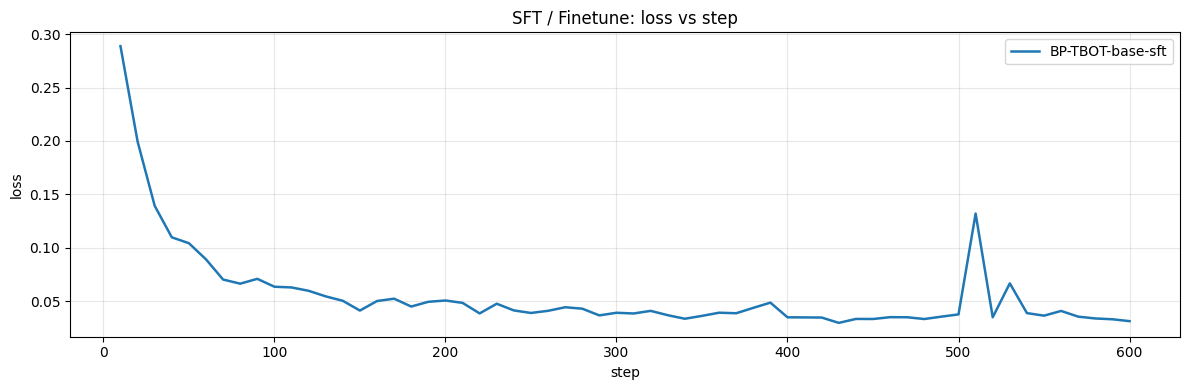

In [5]:
SFT_LOSS_RUNS = [(
        "BP-TBOT-base-sft",
        "/vla/workspace/my_tbot/outputs/BP_TBot/pretrain_v1/2026-07-30/22-39-35_BP_TBot——test/loss.log",
    ),]
SFT_RUN_DFS = show_loss_group(
    title="SFT / Finetune",
    loss_runs=SFT_LOSS_RUNS,
    metrics=SFT_METRICS,
    x_axis="step",
)

### 自应用

In [ ]:
PRETRAIN_LOSS_RUNS = [
    ('pretrain_clean_smoke_sft_v1',
  ('/home/jovyan/vla/workspace/mytbot/outputs/TBot_SA1/2026-07-17/10-22-07_MyTBot_SFT_robotwin_clean_smoke_v1/loss.log')),
  
  ('pretrain_sft_v2',
  ('/home/jovyan/vla/workspace/mytbot/outputs/TBot_SA1/2026-07-18/08-01-34_pretrained_SFT_robotwin_v2/loss.log')),

  (
        "pretrained-sft-v1-14dim",
        OUTPUTS_ROOT / "TBot_SA1/pretrained-sft/12-52-40_MyTBot_SFT_robotwin_v1/loss.log",
    ),
(
        "pretrained-sft-testInitLoss-32dim",
        OUTPUTS_ROOT / "TBot_SA1/2026-07-17/MyTBot_SFT_robotwin_v1_testInitLoss/loss.log",
    ),
    (
        "TBot-sft-v1",
        "/home/jovyan/vla/workspace/mytbot/outputs/TBot_SA1/base-sft/06-19-44_TBot_SFT_robotwin_v0/loss.log",
    ),
]
MIN_STEP = 150000
MAX_STEP = 200000
PRETRAIN_METRICS = ['loss', 'loss_action', 'loss_gen', 'loss_3d'][:2]

In [8]:
# 缩放
METRIC_SCALE_OVERRIDES = {
    ("pretrained-sft-v1-14dim", "loss_action"): 14 / 32,
}

========== clean smoke sft v1 ==========


,run_name,rows,start_step,end_step,start_time,end_time,last_loss,last_loss_action
0,pretrain_clean_smoke_sft_v1,400,100,40000,2026-07-17 10:26:00,2026-07-17 22:32:06,0.015906,0.004634
1,pretrain_sft_v2,2000,100,200000,2026-07-18 08:06:53,2026-07-20 21:24:33,0.015683,0.004085
2,pretrained-sft-v1-14dim,2014,100,200000,2026-07-08 12:57:45,2026-07-14 00:26:52,0.017898,0.002403
3,pretrained-sft-testInitLoss-32dim,6,100,600,2026-07-17 10:02:53,2026-07-17 10:11:51,0.027787,0.012895
4,TBot-sft-v1,2026,100,200000,2026-06-26 06:24:57,2026-06-30 17:02:27,0.014035,0.002824


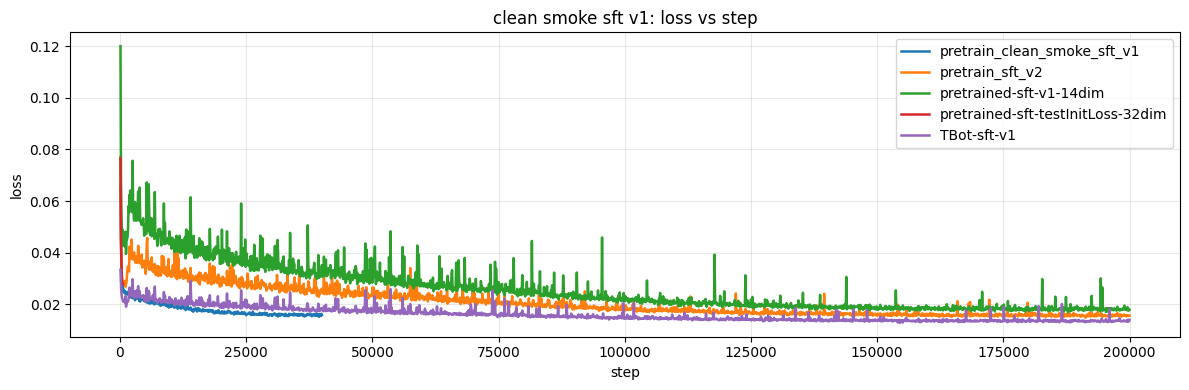

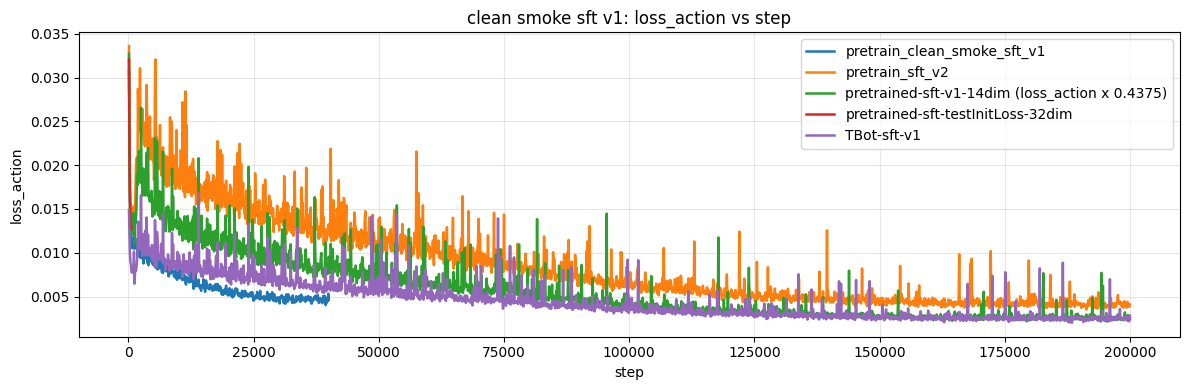

In [9]:
PRETRAIN_RUN_DFS = show_loss_group(
    title="clean smoke sft v1",
    loss_runs=PRETRAIN_LOSS_RUNS,
    metrics=PRETRAIN_METRICS,
    x_axis="step",
)